In [2]:
using IonSim
using QuantumOptics
using PyPlot

In [3]:
function SDF_apply(angle = 0, time = 50.0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    ψ_ion = normalize(ion["g"] -  ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]
return final_state
end


SDF_apply (generic function with 3 methods)

In [4]:
final_state = SDF_apply(π/2, 50.0)
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

Simulating bichromatic displacement...


81×81 Matrix{Float64}:
  1.93787e-12   3.13866e-12  5.02481e-12  …   3.0862e-12    1.90757e-12
  3.02583e-12   4.84296e-12  7.66661e-12      4.76272e-12   2.97906e-12
  4.61377e-12   7.29244e-12  1.14085e-11      7.17344e-12   4.54368e-12
  6.87273e-12   1.0721e-11   1.65676e-11      1.05499e-11   6.77078e-12
  1.00071e-11   1.53995e-11  2.35019e-11      1.51611e-11   9.8631e-12
  1.42531e-11   2.16332e-11  3.26115e-11  …   2.13108e-11   1.40555e-11
  1.9876e-11    2.97607e-11  4.43507e-11      2.93373e-11   1.96123e-11
  2.7166e-11    4.01582e-11  5.92614e-11      3.96163e-11   2.68223e-11
  3.64312e-11   5.32469e-11  7.80289e-11      5.25668e-11   3.59917e-11
  4.79831e-11   6.94957e-11  1.01546e-10      6.86509e-11   4.74271e-11
  ⋮                                       ⋱                 ⋮
 -3.93001e-10  -2.70494e-10  5.05789e-10     -2.52165e-10  -3.83148e-10
 -2.56209e-10  -1.71466e-10  3.56198e-10     -1.59348e-10  -2.49762e-10
 -1.37897e-10  -5.82419e-11  3.32761e-10     -5.0671

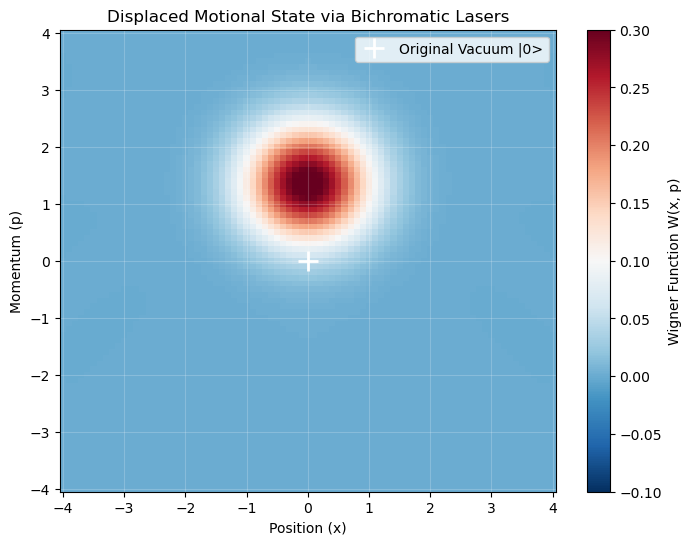

In [5]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


Simulating bichromatic displacement...
Simulating bichromatic displacement...
Simulating bichromatic displacement...
Simulating bichromatic displacement...


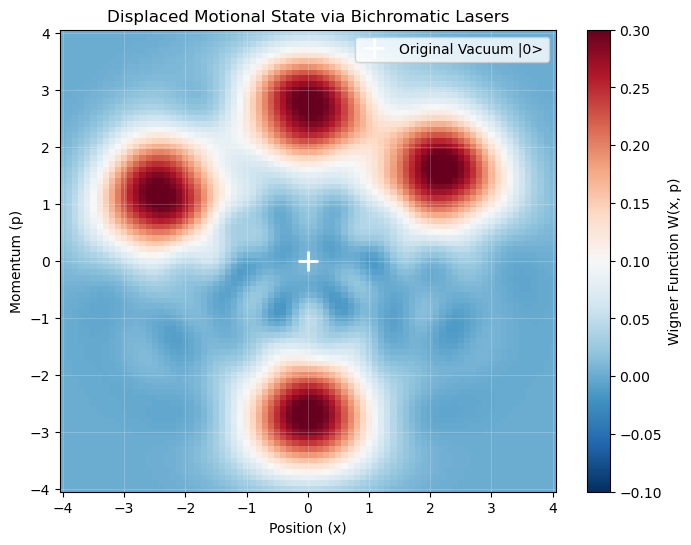

In [6]:
b_fock = FockBasis(10)

final_state1 = SDF_apply(π/2, 100.0)
rho_motional1 = ptrace(final_state1, 1)
rho_fock1 = DenseOperator(b_fock, rho_motional1.data)

final_state2 = SDF_apply(3π/2, 100.0)
rho_motional2 = ptrace(final_state2, 1)
rho_fock2 = DenseOperator(b_fock, rho_motional2.data)

final_state3 = SDF_apply(π/5, 100.0)
rho_motional3 = ptrace(final_state3, 1)
rho_fock3 = DenseOperator(b_fock, rho_motional3.data)

final_state4 = SDF_apply(20*π/7, 100.0)
rho_motional4 = ptrace(final_state4, 1)
rho_fock4 = DenseOperator(b_fock, rho_motional4.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W1 = wigner(rho_fock1, x_vec, p_vec)
W2 = wigner(rho_fock2, x_vec, p_vec)
W3 = wigner(rho_fock3, x_vec, p_vec)
W4 = wigner(rho_fock4, x_vec, p_vec)

W_total = W1 + W2 + W3 + W4

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W_total, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [7]:
function SDF_apply(angle = 0, time = 50.0, cat_state = false)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]

    ψ_ion = normalize(ion["g"] -  ion["e"])

    if cat_state
        println("Preparing cat state superposition...")
        ψ_ion = normalize(ion["g"] +im *  ion["e"])
    end
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]
return final_state
end


SDF_apply (generic function with 4 methods)

Preparing cat state superposition...
Simulating bichromatic displacement...


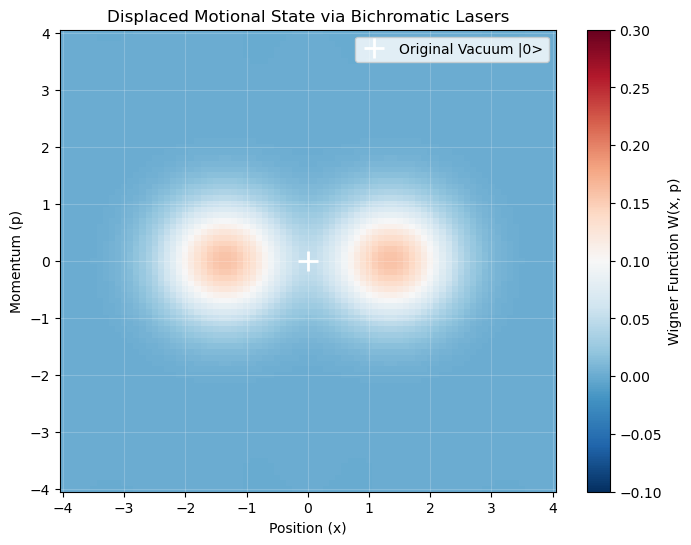

In [8]:
final_state = SDF_apply(0, 50.0, true)
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [9]:
function SDF_apply_with_initial_state(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]
return final_state
end


SDF_apply_with_initial_state (generic function with 5 methods)

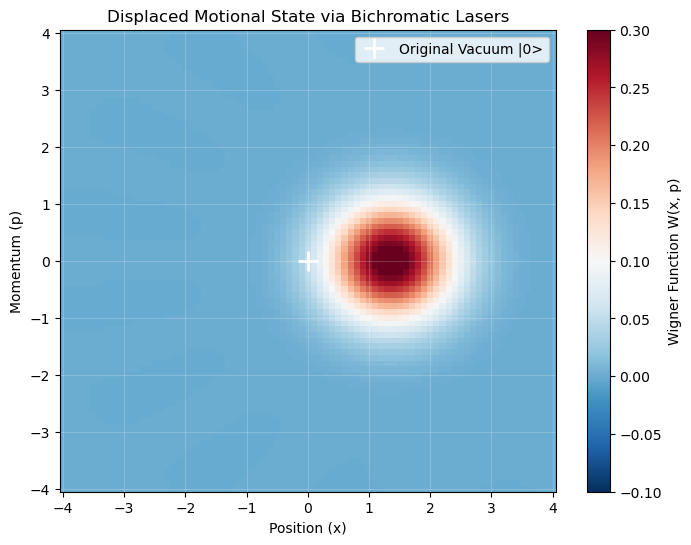

Simulating bichromatic displacement...


In [10]:
final_state = SDF_apply_with_initial_state(0, 50.0, false)
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


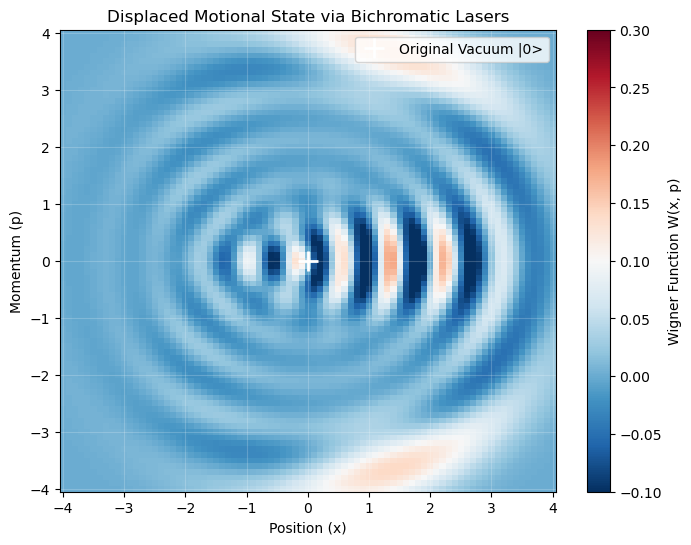

Preparing cat state superposition...
Using provided initial state...
Simulating bichromatic displacement...


In [53]:
final_state = SDF_apply_with_initial_state(pi/2, 50.0, true, final_state)
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [12]:
println(final_state)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
 -0.05132589241788664 + 0.02885949602850146im
 -0.39407348804521136 + 0.02839971546616066im
 -0.04826129852962664 - 0.4268751760696858im
 -0.04844178945579414 - 0.32639709282261015im
   0.5127857285163674 - 0.0280394924868086im
 -0.06896745571333338 - 0.02882075147275122im
 -0.00500634137425244 + 0.24834536765654344im
 -0.00426853424877282 - 0.3204612807923721im
  0.03291927616944419 - 0.01953985904805519im
  0.27045999354125977 - 0.01920807956704141im
  0.01465232348685822 + 0.12939529565326804im
   0.0146422077294471 + 0.10054385044864744im
 -0.08998387377009572 + 0.0049490157585521im
  0.01133675747827401 + 0.00502512295252844im
  0.00053015622936637 - 0.02869834388579433im
  0.00046178195507869 + 0.03632301489706594im
 -0.00252670988576853 + 0.0015545834632259im
 -0.02174449702499566 + 0.00152470110506396im
 -0.00089102838225732 - 0.00781468172139309im
 -0.00088182868451592 - 0.00617038333980452im
  0.00420518076

In [ ]:
function plot_wigner(final_state)
    
rho_motional = ptrace(final_state, 1)
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W', cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

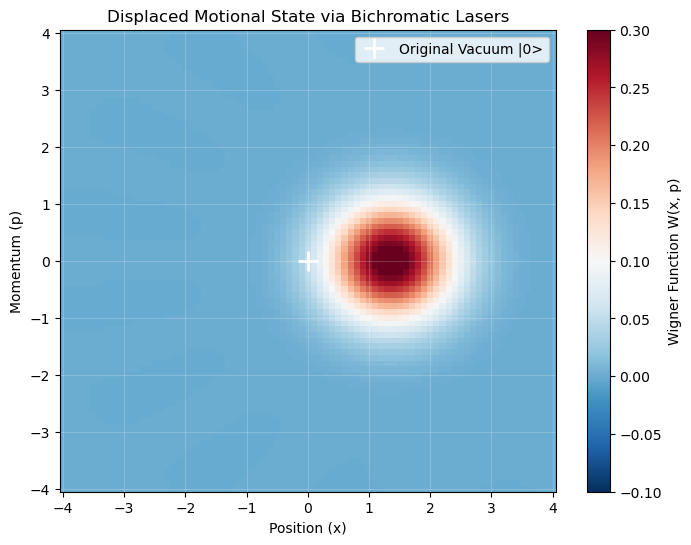

Simulating bichromatic displacement...


In [14]:
final_state = SDF_apply_with_initial_state(0, 50.0, false)
plot_wigner(final_state)

In [31]:
 L_red = Laser(Δ = -trap_freq, ϕ=0, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=pi, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    
    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.7071067811865475 + 0.0im
 -0.7071067811865475 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                     ⋮
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im

In [43]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0
Omega_eff = laser_intensity * geometric_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# println(ψ_initial)

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t
alpha_mag = 0.5 * eta * Omega_eff * tspan_end

println("-----------------------------------------")
println("THEORETICAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 1.0e6 rad/s
-----------------------------------------
THEORETICAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 1.243
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.4468734414335571 - 0.00034483370182334im
  -0.4466362681303497 + 0.00034499739855128im
  0.00033004943943838 + 0.42837077917749894im
 -0.00033042024163522 - 0.4283709026404941im
  -0.2899923199835116 + 0.00022325770393111im
  0.29017407056827754 - 0.00022335265454717im
 -0.00012319845984531 - 0.16019425945973778im
  0.00012308764852718 + 0.16019384386177352im
  0.07645062533844156 - 5.872103474384e-5im
 -0.07658672561145687 + 5.875852965159e-5im
     2.50984533427e-5

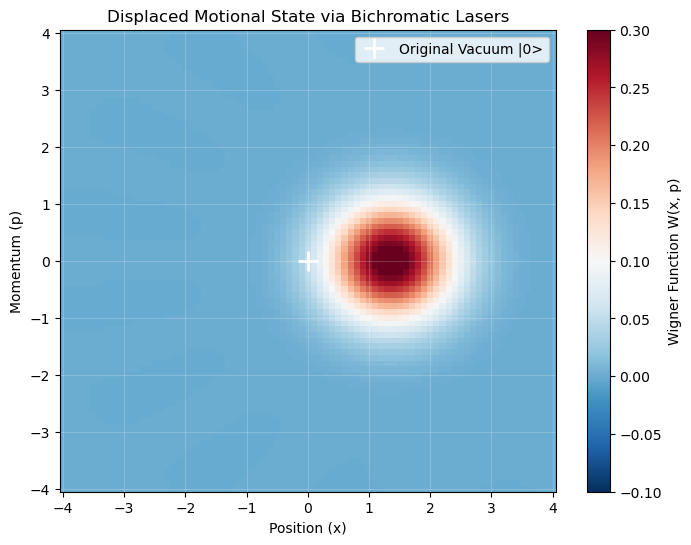

In [44]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [49]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = sqrt(0.918)  

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.44683155480359943 + 0.0im
 -0.44683155480359943 + 0.0im
   0.4281196636710952 + 0.0im
  -0.4281196636710952 + 0.0im
     0.29004909741155 + 0.0im
    -0.29004909741155 + 0.0im
  0.16044723286991655 + 0.0im
 -0.16044723286991655 + 0.0im
    0.076864105636757 + 0.0im
   -0.076864105636757 + 0.0im
  0.03293516790298326 + 0.0im
 -0.03293516790298326 + 0.0im
  0.01288268030604424 + 0.0im
 -0.01288268030604424 + 0.0im
  0.00466517302908638 + 0.0im
 -0.00466517302908638 + 0.0im
  0.00158094571314302 + 0.0im
 -0.00158094571314302 + 0.0im
  0.00050190439338203 + 0.0im
 -0.00050190439338203 + 0.0im
   0.0001647917325806 + 0.0im
  -0.0001647917325806 + 0.0im


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.44683155480359943 + 0.0im
 -0.44683155480359943 + 0.0im
   0.4281196636710952 + 0.0im
  -0.4281196636710952 + 0.0im
     0.29004909741155 + 0.0im
    -0.29004909741155 + 0.0im
  0.16044723286991655 + 0.0im
 -0.16044723286991655 + 0.0im
    0.076864105636757 + 0.0im
   -0.076864105636757 + 0.0im
  0.03293516790298326 + 0.0im
 -0.03293516790298326 + 0.0im
  0.01288268030604424 + 0.0im
 -0.01288268030604424 + 0.0im
  0.00466517302908638 + 0.0im
 -0.00466517302908638 + 0.0im
  0.00158094571314302 + 0.0im
 -0.00158094571314302 + 0.0im
  0.00050190439338203 + 0.0im
 -0.00050190439338203 + 0.0im
   0.0001647917325806 + 0.0im
  -0.0001647917325806 + 0.0im


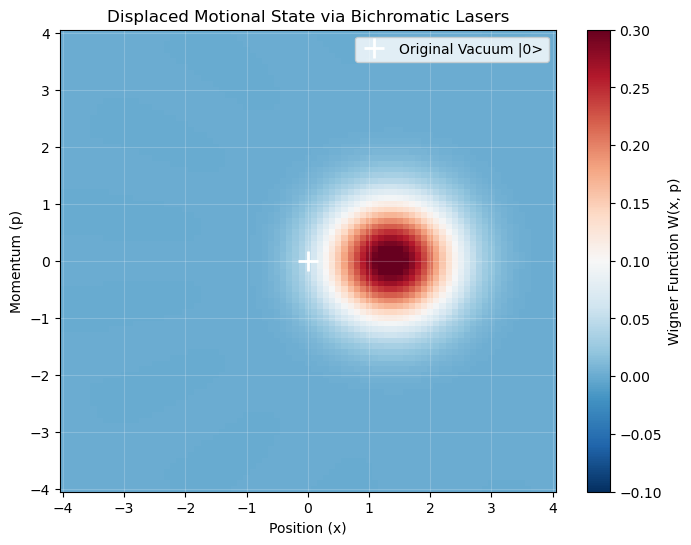

sys:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


In [55]:
println(displaced_final_state)
plot_wigner(displaced_final_state)

In [ ]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1
geometric_factor = 1.0
cg_factor = sqrt(3/5)  # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 774596.6692414834 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.963
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.4468734414335571 - 0.00034483370182334im
  -0.4466362681303497 + 0.00034499739855128im
  0.00033004943943838 + 0.42837077917749894im
 -0.00033042024163522 - 0.4283709026404941im
  -0.2899923199835116 + 0.00022325770393111im
  0.29017407056827754 - 0.00022335265454717im
 -0.00012319845984531 - 0.16019425945973778im
  0.00012308764852718 + 0.16019384386177352im
  0.07645062533844156 - 5.872103474384e-5im
 -0.07658672561145687 + 5.875852965159e-5im
     2.50984533

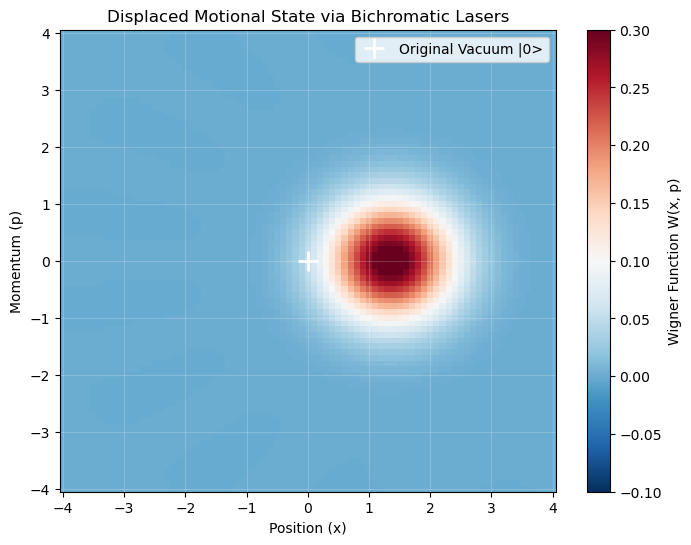

In [48]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [40]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.961 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.44559977723976246 + 0.0im
 -0.44559977723976246 + 0.0im
                  0.0 + 0.42822138592721576im
                  0.0 - 0.42822138592721576im
  -0.2909891142535148 + 0.0im
   0.2909891142535148 + 0.0im
                  0.0 - 0.16145054031616207im
                  0.0 + 0.16145054031616207im
  0.07757698496065443 + 0.0im
 -0.07757698496065443 + 0.0im
                  0.0 + 0.03334043378145188im
                  0.0 - 0.03334043378145188im
 -0.01308035890931485 + 0.0im
  0.01308035890931485 + 0.0im
                  0.0 - 0.00475097738700115im
                  0.0 + 0.00475097738700115im
  0.00161486964129921 + 0.0im
 -0.00161486964129921 + 0.0im
                  0.0 + 0.00051417461018705im
                  0.0 - 0.00051417461018705im
  -0.0001694133556125 + 0.0im
   0.0001694133556125 + 0.0im


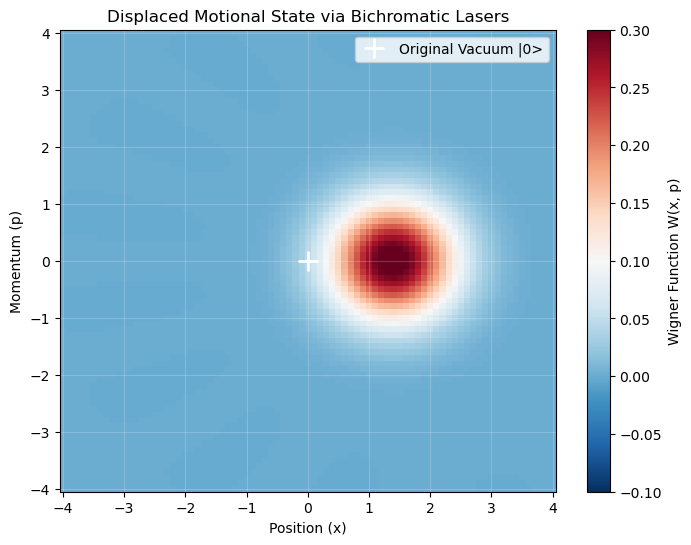

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.4373272141496584 + 0.0im
  -0.4373272141496584 + 0.0im
                  0.0 + 0.4287145246413377im
                  0.0 - 0.4287145246413377im
  -0.2971767942166392 + 0.0im
   0.2971767942166392 + 0.0im
                  0.0 - 0.16819611483429384im
                  0.0 + 0.16819611483429384im
  0.08244183703192068 + 0.0im
 -0.08244183703192068 + 0.0im
                  0.0 + 0.03614300900002448im
                  0.0 - 0.03614300900002448im
 -0.01446475810577933 + 0.0im
  0.01446475810577933 + 0.0im
                  0.0 - 0.00535933375729991im
                  0.0 + 0.00535933375729991im
  0.00185834724337966 + 0.0im
 -0.00185834724337966 + 0.0im
                  0.0 + 0.00060326587110857im
                  0.0 - 0.00060326587110857im
  -0.0002034627190209 + 0.0im
   0.0002034627190209 + 0.0im


In [39]:
println(displaced_final_state)
plot_wigner(displaced_final_state)

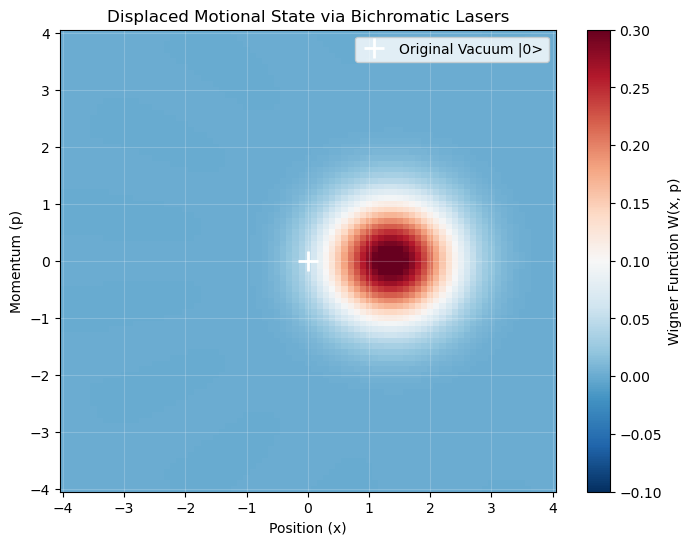

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.4468842840380298 + 0.0im
  -0.4468842840380298 + 0.0im
                  0.0 + 0.42811514410824864im
                  0.0 - 0.42811514410824864im
 -0.29000875042623353 + 0.0im
  0.29000875042623353 + 0.0im
                  0.0 - 0.16040429162763137im
                  0.0 + 0.16040429162763137im
  0.07683365601035978 + 0.0im
 -0.07683365601035978 + 0.0im
                  0.0 + 0.03291788858712283im
                  0.0 - 0.03291788858712283im
 -0.01287426624866148 + 0.0im
  0.01287426624866148 + 0.0im
                  0.0 - 0.00466152688086481im
                  0.0 + 0.00466152688086481im
   0.0015795065244889 + 0.0im
  -0.0015795065244889 + 0.0im
                  0.0 + 0.0005013846515914im
                  0.0 - 0.0005013846515914im
 -0.00016459635054807 + 0.0im
  0.00016459635054807 + 0.0im


In [ ]:
# 1. Grab the exact mode object used in the simulation
sim_mode = zmodes(trap)[1]
a = 0.958 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() numerical method
D_motion = IonSim.displace(sim_mode, a)
ψ_ion = normalize(ion["g"] -  ion["e"])

# 3. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 4. Apply the operator to the state
displaced_final_state = D_system * ψ_initial
println(displaced_final_state)
plot_wigner(displaced_final_state)